# Malaria model-selection run — cross-window ranking

You pick **one** model for all forecasts, so the temporal windows collapse into a **single ranking**: how consistently good is each spec across every window? We rank each spec *within* each window, then aggregate across windows with three methods (Borda, TOPSIS, pairwise dominance) from `select.model_selection` — favouring specs where the methods **converge**.

Metric is `oos_pfpr_r` (out-of-sample PfPR-space Pearson correlation) per window, higher = better. **No in-sample metrics** — AIC etc. play no role in selection here.

> **Leakage caveat (read before trusting lag results):** the lag covariate uses *observed* national PfPR at year−lag, which in these gapped windows falls after `train_hi`. Lag models therefore see near-contemporaneous national malaria level that the FE models don't — and that a real forecast wouldn't have. So a lag-beats-FE result here is expected and largely an artifact until the recursive-national-forecast experiment supplies forecasted (not observed) national PfPR.

In [ ]:
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_forecast_mbp.select.model_selection import (
    borda_rank, topsis_rank, pairwise_dominance_summary,
)

%matplotlib inline
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)

# >>> the only thing to change per run <<<
# FE-only run (20260707_efs_v2): 459 FE specs, full unrestricted data (2000+), 10 windows.
# The lag-specific cells below (FE-vs-lag, lag picks) are moot for this FE-only run.
RUN_DIR = Path('/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_prelim/lsae_1285/20260707_efs_v2')

In [2]:
# --- load: bundled select_summary files + param_map (expected) + spec metadata ---
files = sorted(glob.glob(str(RUN_DIR / 'select_summary_*_n*_bin*.parquet')))
pm = pd.read_parquet(RUN_DIR / 'param_map.parquet')
spec = pd.read_parquet(RUN_DIR / 'spec_table.parquet').set_index('spec_index')

df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
df['cell'] = df['task_id'].map(lambda t: t.rsplit('_n', 1)[0])   # strip _n<ns>_bin<idx>

print(f'select_summary files : {len(files)}')
print(f'tasks expected (pm)  : {pm.task_id.nunique()}')
print(f'specs expected       : {spec.shape[0]}')
print(f'specs present        : {df.spec_index.nunique()}')
print(f'cells present        : {sorted(df.cell.unique())}')

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/team/idd/pub/forecast-mbp/03-modeling_data/malaria/scam_prelim/lsae_1285/20260720_efs/param_map.parquet'

In [52]:
df.columns

Index(['task_id', 'spec_index', 'optimizer', 'maxit_setting', 'r_version', 'scam_version', 'did_is_fe', 'did_oos', 'is_formula', 'is_elapsed_sec', 'is_error', 'is_error_msg', 'is_iter',
       'is_converged', 'is_aic', 'is_bic', 'is_loglik', 'is_deviance', 'is_null_deviance', 'is_dev_expl', 'is_r_sq', 'is_ssr', 'is_rmse', 'is_mae', 'is_pfpr_ssr', 'is_pfpr_rmse', 'is_pfpr_mae',
       'is_pfpr_r', 'is_n_obs', 'is_n_coef', 'is_edf_sum', 'is_edf_smooth', 'is_edf_parametric', 'is_n_smooths', 'is_max_sp', 'is_min_sp', 'is_smooth_labels', 'is_coef', 'is_edf_per_smooth',
       'is_sp_per_smooth', 'total_elapsed_sec', 'cv_strategy', 'cv_n_folds', 'cv_seed', 'cv_train_lo', 'cv_train_hi', 'cv_test_lo', 'cv_test_hi', 'cv_elapsed_sec', 'cv_iter_per_fold',
       'cv_converged_per_fold', 'cv_n_converged', 'oos_ssr', 'oos_rmse', 'oos_mae', 'oos_r_sq', 'oos_pfpr_ssr', 'oos_pfpr_rmse', 'oos_pfpr_mae', 'oos_pfpr_r', 'oos_n_obs', 'oos_n_folds_ok',
       'cv_fold_rmse_per_fold', 'cv_fold_mae_per_fold',

In [67]:
# --- per-spec table: 3 PfPR-space metrics x each temporal window, OOS + in-sample ---
oos_metrics = {'oos_pfpr_r': 'higher', 'oos_pfpr_rmse': 'lower', 'oos_pfpr_mae': 'lower'}
is_metrics  = {'is_aic': 'lower', 'is_pfpr_r': 'higher', 'is_pfpr_rmse': 'lower', 'is_pfpr_mae': 'lower'}
oos = df[df.cell != 'IS'][['spec_index', 'cell'] + list(oos_metrics)]
is_df = df[df.cell == 'IS'][['spec_index'] + list(is_metrics)].set_index('spec_index')
wide = oos.pivot_table(index='spec_index', columns='cell', values=list(oos_metrics))
wide.columns = [f'{cell}__{metric}' for metric, cell in wide.columns]   # (metric,cell) -> <cell>__<metric>
oos_cols = list(wide.columns)                                           # OOS: <cell>__<metric>
wide = wide.join(is_df, how='left')                                     # add IS cols: is_aic, is_pfpr_r, ...

metric_cols = oos_cols + list(is_metrics)                               # OOS + IS, both ranked
win_metrics = {c: oos_metrics[c.rsplit('__', 1)[1]] for c in oos_cols}  # OOS directions
# win_metrics.update(is_metrics)                                          # IS directions
window_cols = [c for c in oos_cols if c.endswith('__oos_pfpr_r')]       # r-only, for per-window displays

tab = wide.join(spec[['n_smooths', 'formula_text']], how='left').reset_index()
f = tab['formula_text']
tab['country_term'] = np.select(
    [f.str.contains('a0_malaria_pfpr_lag1', regex=False),
     f.str.contains('a0_malaria_pfpr_lag2', regex=False),
     f.str.contains('a0_malaria_pfpr_lag3', regex=False),
     f.str.contains('A0_af', regex=False)],
    ['lag1', 'lag2', 'lag3', 'FE'], default='none')
tab['suitability'] = f.str.contains('malaria_suit', regex=False)
tab['temperature'] = f.str.contains('mean_temperature', regex=False) | f.str.contains('mean_low_temperature', regex=False)
tab['humidity']    = f.str.contains('relative_humidity', regex=False)
tab['urban']       = f.str.contains('weighted_1km_urban', regex=False)
tab['precip']      = f.str.contains('total_precipitation', regex=False)


In [68]:
n_missing = tab[window_cols].isna().any(axis=1).sum()
print(f'specs with a missing window (excluded from ranking): {n_missing} of {len(tab)}')
ranked = tab.dropna(subset=window_cols).copy()
ranked = ranked[ranked['country_term'] == 'FE'].copy()   # cull to FE only
# per-spec rank WITHIN each window (1 = best oos_pfpr_r in that window)
rank_by_win = ranked.set_index('spec_index')[window_cols].rank(ascending=False, method='min')
rank_by_win['country_term'] = ranked.set_index('spec_index')['country_term']
rank_by_win.head()

specs with a missing window (excluded from ranking): 0 of 459


,exwide_recent__oos_pfpr_r,narrow_full__oos_pfpr_r,narrow_preC__oos_pfpr_r,narrow_recent__oos_pfpr_r,vwide_full__oos_pfpr_r,vwide_preC__oos_pfpr_r,vwide_recent__oos_pfpr_r,wide_full__oos_pfpr_r,wide_preC__oos_pfpr_r,wide_recent__oos_pfpr_r,country_term
spec_index,,,,,,,,,,,
1,150.0,61.0,50.0,351.0,40.0,39.0,298.0,47.0,44.0,338.0,FE
2,18.0,17.0,17.0,14.0,15.0,20.0,14.0,17.0,17.0,13.0,FE
3,9.0,11.0,11.0,9.0,6.0,6.0,9.0,8.0,8.0,8.0,FE
4,156.0,54.0,47.0,336.0,42.0,42.0,288.0,49.0,46.0,318.0,FE
5,19.0,21.0,24.0,8.0,27.0,34.0,13.0,21.0,24.0,9.0,FE


## 1. Cross-window aggregate ranking (Borda / TOPSIS / dominance)

The 8 per-window `oos_pfpr_r` columns are the metrics (all higher-better). `borda_rank` also draws its elbow plot (suggested top-tier cutpoint). `consensus_rank` = mean of the three method ranks — low + agreement across methods is the strong signal.

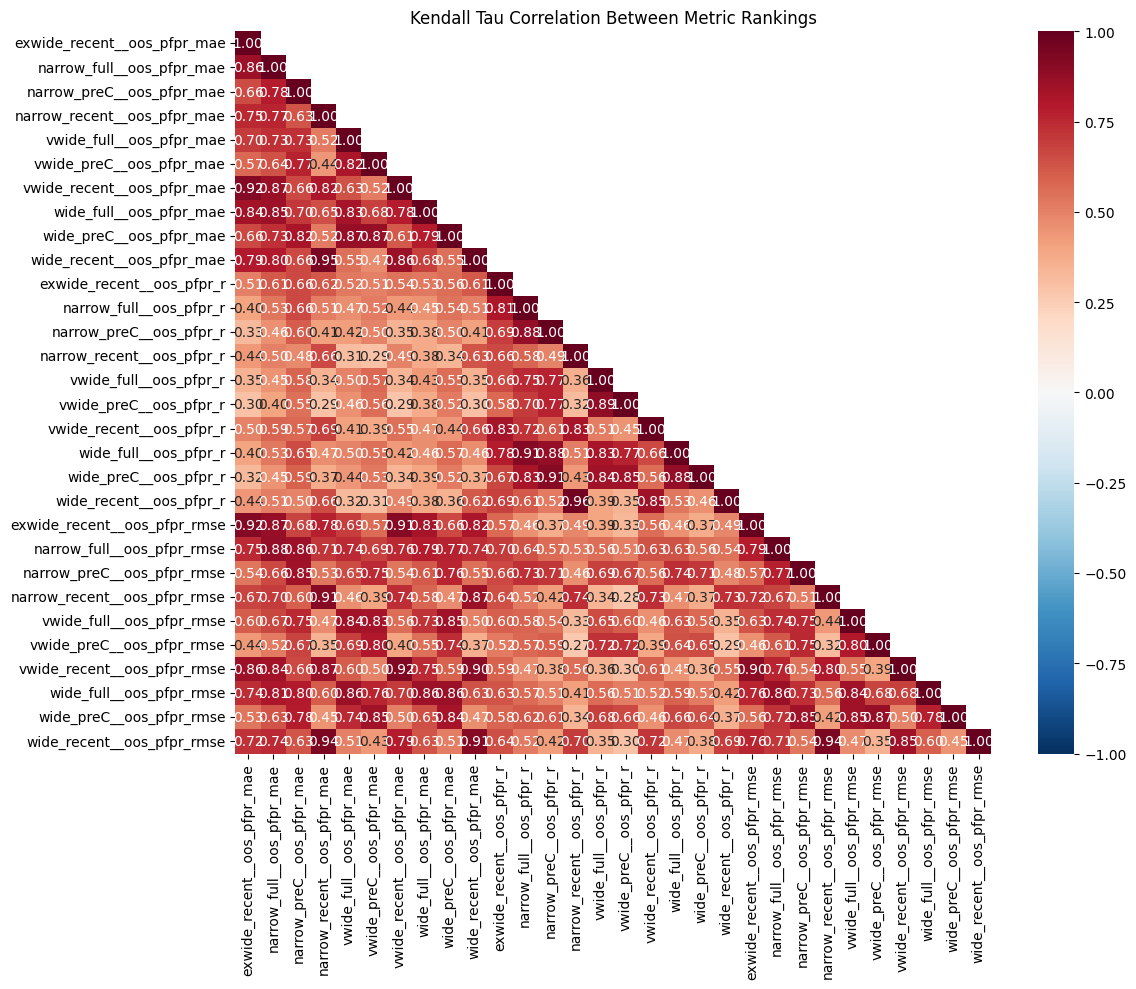


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.603
Pairs with negative correlation: 0
Metrics largely agree. Flat top tier likely reflects genuine equivalence.
step 1: |τ|=0.962  narrow_recent__oos_pfpr_r (0.483) vs wide_recent__oos_pfpr_r (0.497)  → drop wide_recent__oos_pfpr_r
step 2: |τ|=0.949  narrow_recent__oos_pfpr_mae (0.595) vs wide_recent__oos_pfpr_mae (0.609)  → drop wide_recent__oos_pfpr_mae
step 3: |τ|=0.944  narrow_recent__oos_pfpr_rmse (0.556) vs wide_recent__oos_pfpr_rmse (0.581)  → drop wide_recent__oos_pfpr_rmse
step 4: |τ|=0.925  vwide_recent__oos_pfpr_mae (0.586) vs vwide_recent__oos_pfpr_rmse (0.594)  → drop vwide_recent__oos_pfpr_rmse
step 5: |τ|=0.921  exwide_recent__oos_pfpr_mae (0.573) vs exwide_recent__oos_pfpr_rmse (0.603)  → drop exwide_recent__oos_pfpr_rmse
step 6: |τ|=0.916  exwide_recent__oos_pfpr_mae (0.558) vs vwide_recent__oos_pfpr_mae (0.558)  → drop exwide_recent__oos_pfpr_mae
step 7: |τ|=0.909  narrow_preC__oos_pfpr_r (0.575) vs w

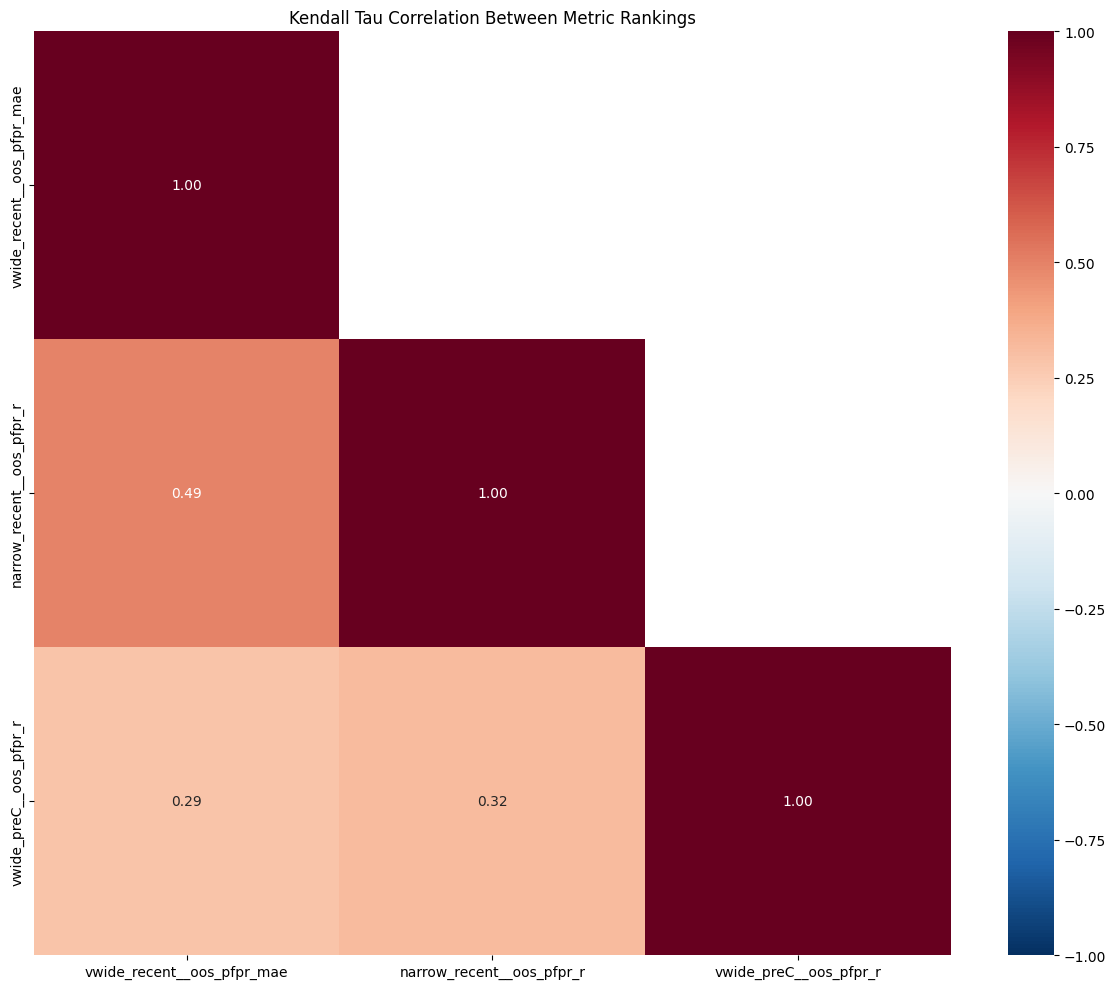


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.366
Pairs with negative correlation: 0
Moderate agreement. Some trade-offs between metrics.


,vwide_recent__oos_pfpr_mae,narrow_recent__oos_pfpr_r,vwide_preC__oos_pfpr_r
vwide_recent__oos_pfpr_mae,1.00,0.49,0.29
narrow_recent__oos_pfpr_r,0.49,1.00,0.32
vwide_preC__oos_pfpr_r,0.29,0.32,1.00


In [69]:
from idd_forecast_mbp.select.model_selection import kendall_tau_heatmap, prune_redundant_metrics
# use metric_cols (r + rmse + mae x windows) and the DIRECTIONAL win_metrics from the build cell
mdf = ranked[['spec_index', 'country_term', 'n_smooths'] + metric_cols].copy()
mdf['task_id'] = mdf['spec_index'].astype(str)   # CONFIG_COLS display hook (harmless)

tau_df = kendall_tau_heatmap(mdf, win_metrics, plot=True)
win_metrics, prune_log = prune_redundant_metrics(tau_df, win_metrics, threshold=0.7)
tau_df = kendall_tau_heatmap(mdf, win_metrics, plot=True)
tau_df.round(2)


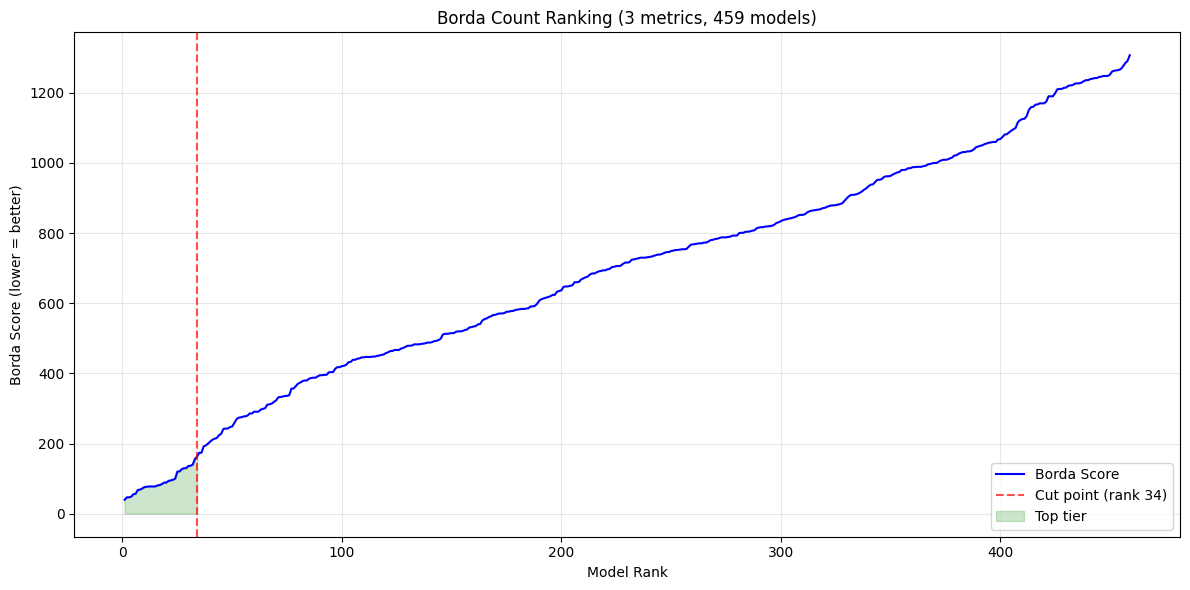


=== Borda Count Summary ===
Total models: 459
Metrics used: 3
Suggested cutpoint: rank 34 (top 34 models)
Top tier Borda range: 40.0 - 163.0
Bottom tier starts at: 174.0


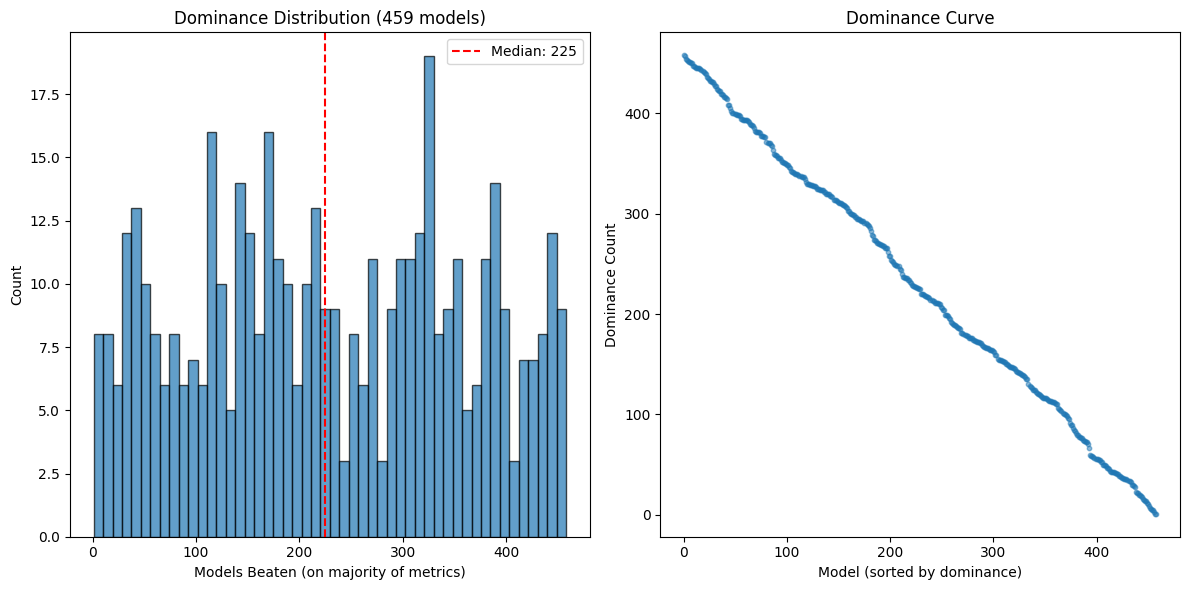


=== Pairwise Dominance Summary ===
Models compared: 459
Metrics used: 3
Max dominance: 458 / 458 models beaten
Median dominance: 225

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct task_id
0             1.0              458     100.000000      12
1             2.0              457      99.781659      13
2             3.0              454      99.126638      47
3             4.0              453      98.908297      30
4             5.0              452      98.689956      46
5             6.5              451      98.471616      29
6             6.5              451      98.471616      16
7             8.5              450      98.253275       5
8             8.5              450      98.253275       6
9            10.5              447      97.598253       3
Borda elbow cutpoint: top 34 specs


,spec_index,country_term,n_smooths,borda_rank,topsis_rank,dominance_rank,consensus_rank
0,13,FE,2,1.0,1.0,2.0,1.33
1,15,FE,4,4.0,2.0,10.5,5.50
2,16,FE,3,6.0,3.0,6.5,5.17
3,12,FE,3,2.5,4.0,1.0,2.50
4,6,FE,2,2.5,5.0,8.5,5.33
5,5,FE,3,5.0,6.0,8.5,6.50
6,30,FE,2,9.0,7.0,4.0,6.67
7,32,FE,4,8.0,8.0,19.0,11.67
8,49,FE,5,11.0,9.0,18.0,12.67
9,23,FE,2,7.0,10.0,14.5,10.50


In [70]:
# country_terms_to_keep = ['lag3', 'FE']
# mdf = mdf[mdf['country_term'].isin(country_terms_to_keep)].copy()

borda_df, borda_cut = borda_rank(mdf, win_metrics, plot=True)
topsis_df, _infl = topsis_rank(mdf, win_metrics, verbose=False)
dom_df = pairwise_dominance_summary(mdf, win_metrics)

agg = (ranked[['spec_index', 'country_term', 'n_smooths']]
       .merge(borda_df[['spec_index', 'borda_rank', 'borda_score']], on='spec_index')
       .merge(topsis_df[['spec_index', 'topsis_rank', 'topsis_score']], on='spec_index')
       .merge(dom_df[['spec_index', 'dominance_rank', 'dominance_count']], on='spec_index'))
agg['consensus_rank'] = agg[['borda_rank', 'topsis_rank', 'dominance_rank']].mean(axis=1)
agg = agg.sort_values('topsis_rank').reset_index(drop=True)
print(f'Borda elbow cutpoint: top {borda_cut} specs')
agg[['spec_index', 'country_term', 'n_smooths', 'borda_rank', 'topsis_rank', 'dominance_rank', 'consensus_rank']].head(15).round(2)

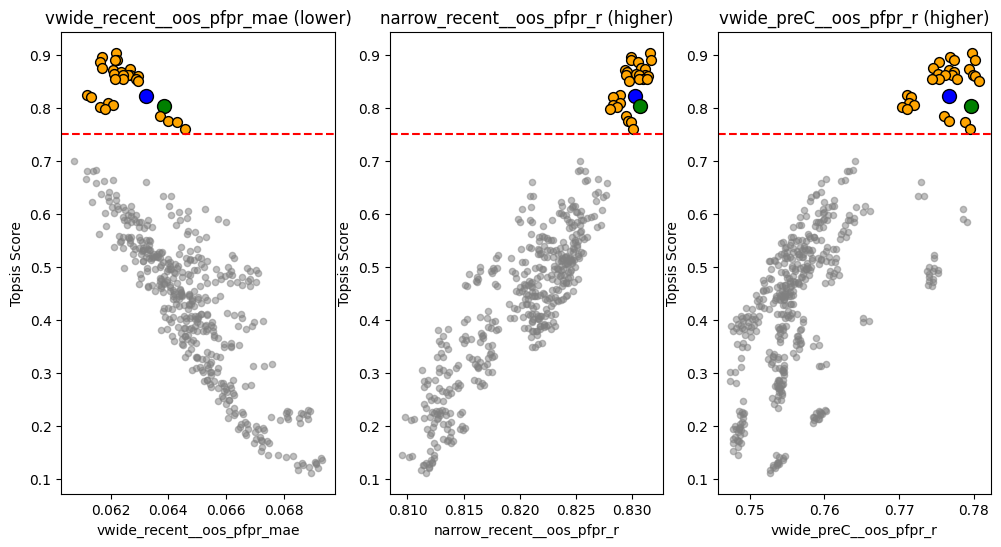

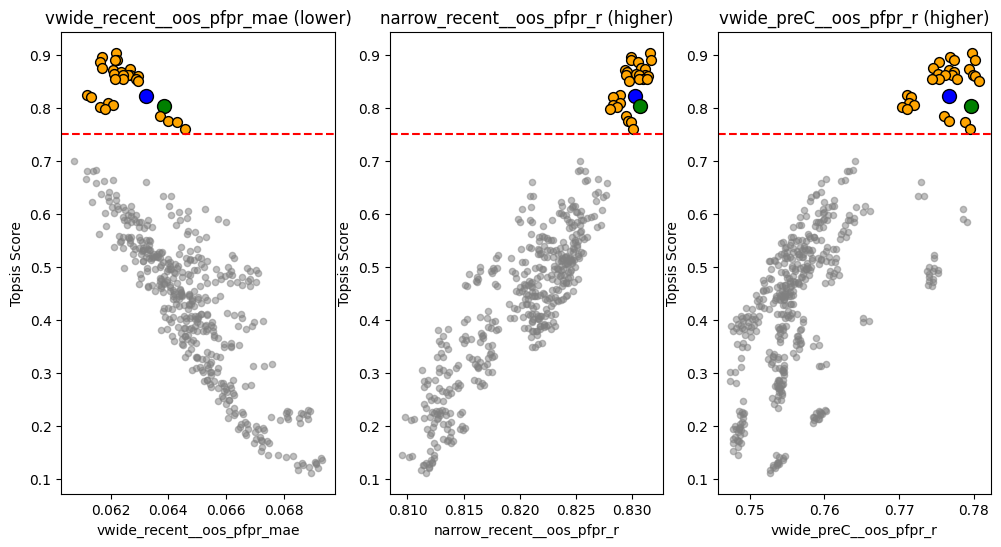

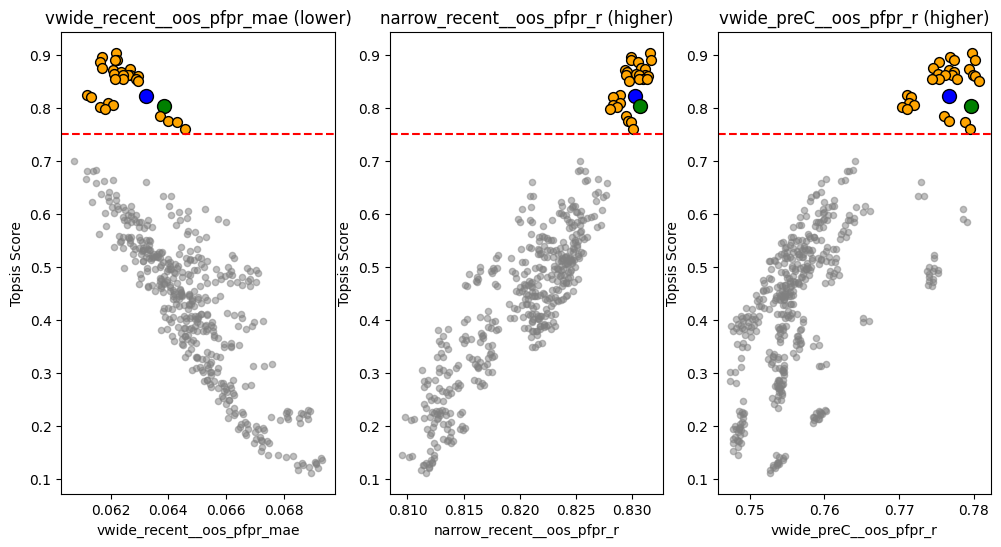

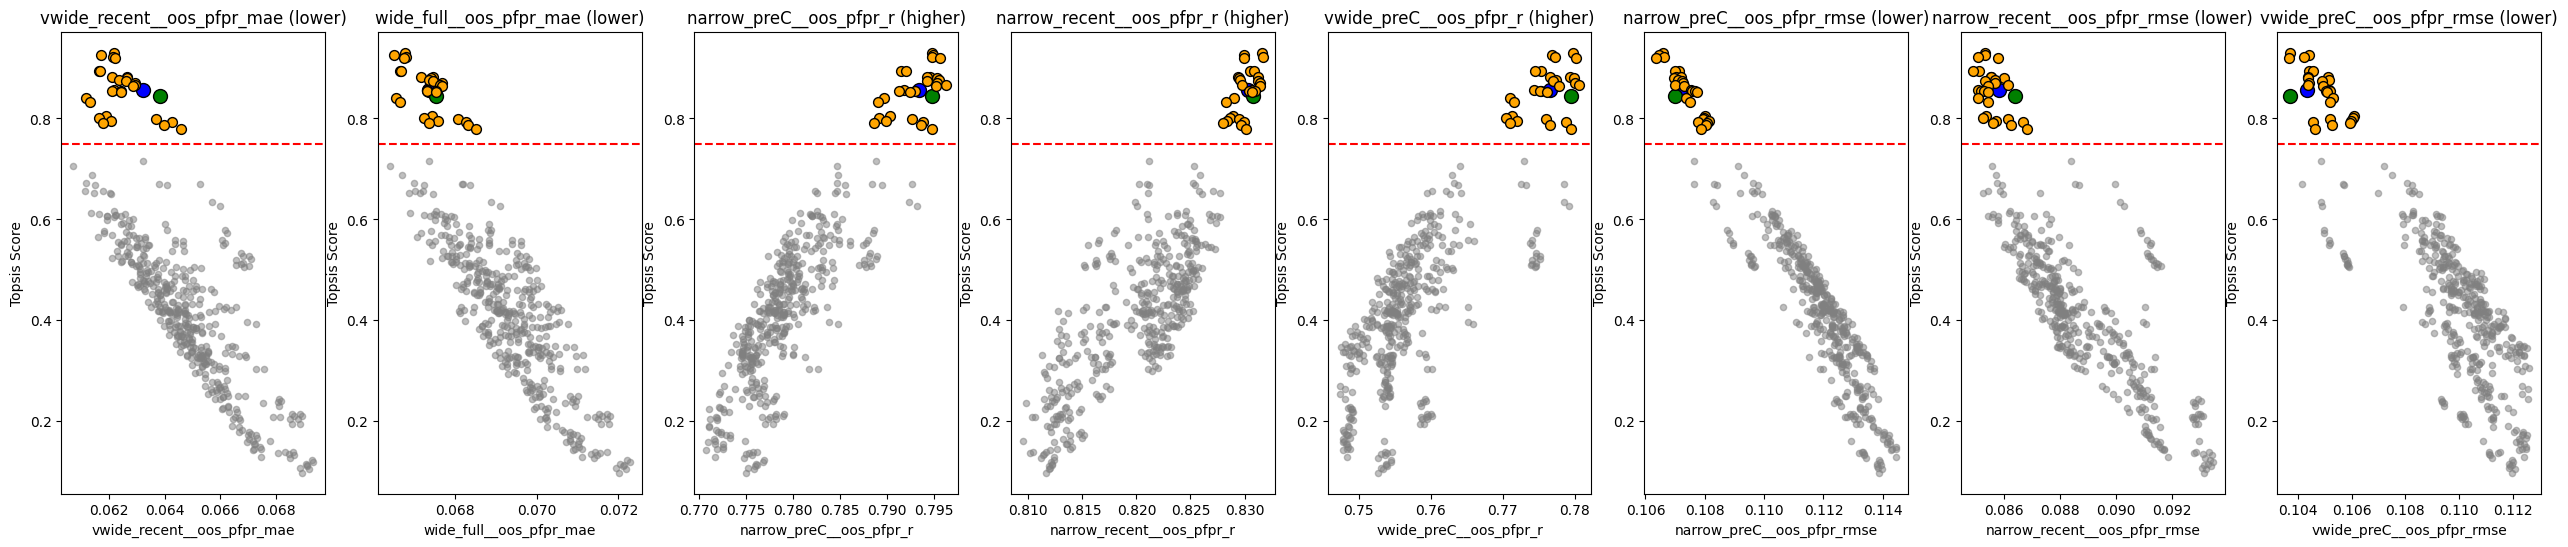

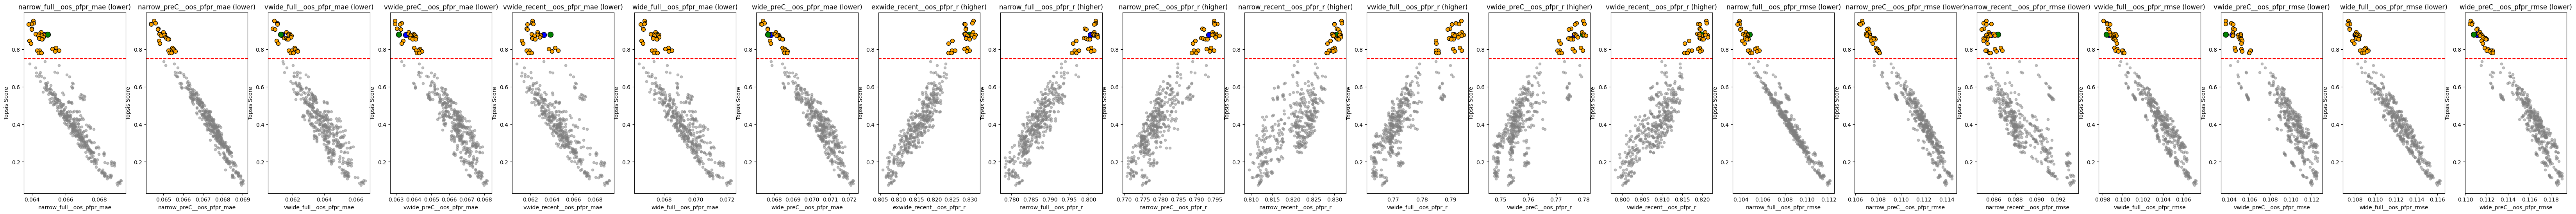

In [71]:
from idd_forecast_mbp.select.model_selection import kendall_tau_heatmap, prune_redundant_metrics
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
aggs = []
for threshold in thresholds:
    wm = {c: oos_metrics[c.rsplit('__', 1)[1]] for c in oos_cols}  # OOS directions
    # wm.update(is_metrics)
    mdf = ranked[['spec_index', 'country_term', 'n_smooths'] + metric_cols].copy()
    mdf['task_id'] = mdf['spec_index'].astype(str)

    tau_df = kendall_tau_heatmap(mdf, wm, plot=False, verbose=False)
    wm, prune_log = prune_redundant_metrics(tau_df, wm, threshold=threshold, verbose=False)

    borda_df, borda_cut = borda_rank(mdf, wm, plot=False)
    topsis_df, _infl = topsis_rank(mdf, wm, verbose=False)
    dom_df = pairwise_dominance_summary(mdf, wm, plot=False, verbose=False)

    topsis_threshold = 0.75
    fig, axes = plt.subplots(1, len(wm), figsize=(4 * len(wm), 6))
    for i, col in enumerate(wm.keys()):
        ax = axes[i]
        spec_2_df = topsis_df[topsis_df['spec_index'] == 2]
        spec_3_df = topsis_df[topsis_df['spec_index'] == 3]
        good_spec_df = topsis_df[(topsis_df['topsis_score'] > topsis_threshold) & (topsis_df['spec_index'] != 2) & (topsis_df['spec_index'] != 3)]
        rest_spec_df = topsis_df[(topsis_df['topsis_score'] <= topsis_threshold) & (topsis_df['spec_index'] != 2) & (topsis_df['spec_index'] != 3)]
        ax.scatter(spec_2_df[col], spec_2_df['topsis_score'], color='blue', label='Spec 2', s=100, edgecolor='black')
        ax.scatter(spec_3_df[col], spec_3_df['topsis_score'], color='green', label='Spec 3', s=100, edgecolor='black')
        ax.scatter(good_spec_df[col], good_spec_df['topsis_score'], color='orange', label='Good Specs', s=50, edgecolor='black')
        ax.scatter(rest_spec_df[col], rest_spec_df['topsis_score'], color='gray', label='Rest Specs', s=20, alpha=0.5)
        ax.axhline(y=topsis_threshold, color='r', linestyle='--', label=f'Topsis Score Threshold ({topsis_threshold})')
        ax.set_xlabel(col)
        ax.set_ylabel('Topsis Score')
        ax.set_title(f'{col} ({wm[col]})')



    agg = (ranked[['spec_index', 'country_term', 'n_smooths']]
        .merge(borda_df[['spec_index', 'borda_rank', 'borda_score']], on='spec_index')
        .merge(topsis_df[['spec_index', 'topsis_rank', 'topsis_score']], on='spec_index')
        .merge(dom_df[['spec_index', 'dominance_rank', 'dominance_count']], on='spec_index'))
    agg['consensus_rank'] = agg[['borda_rank', 'topsis_rank', 'dominance_rank']].mean(axis=1)
    agg = agg.sort_values('topsis_rank').reset_index(drop=True)
    agg['prune_threshold'] = threshold
    aggs.append(agg)
aggs = pd.concat(aggs, ignore_index=True)


In [64]:
cutoff = 0.75
hit_counts = (aggs.assign(hit=aggs['topsis_score'] > cutoff)
              .groupby('spec_index')['hit'].sum()
              .astype(int).sort_values(ascending=False))

print(len(hit_counts[hit_counts > 0]))        # specs that clear 0.8 in >=1 threshold, most-robust first
# save the specs that clear the cutoff in at least one threshold
final_specs = pd.DataFrame({
    'spec_index': hit_counts[hit_counts > 0].index,
    'hit_count': hit_counts[hit_counts > 0].values
}).reset_index(drop=True)

final_ranked = ranked[ranked.spec_index.isin(final_specs.spec_index)].copy()

35


In [66]:
final_ranked

,spec_index,exwide_recent__oos_pfpr_mae,narrow_full__oos_pfpr_mae,narrow_preC__oos_pfpr_mae,narrow_recent__oos_pfpr_mae,vwide_full__oos_pfpr_mae,vwide_preC__oos_pfpr_mae,vwide_recent__oos_pfpr_mae,wide_full__oos_pfpr_mae,wide_preC__oos_pfpr_mae,...,is_pfpr_rmse,is_pfpr_mae,n_smooths,formula_text,country_term,suitability,temperature,humidity,urban,precip
1,2,0.063813,0.064735,0.065029,0.054334,0.061327,0.063551,0.063220,0.067351,0.067827,...,0.103708,0.057466,3,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + s(malaria_suit, k = 6, bs = ""mpi"") + A0_af",FE,True,False,False,False,False
2,3,0.064691,0.064928,0.064932,0.054768,0.061243,0.063166,0.063848,0.067535,0.067684,...,0.103468,0.057230,2,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + logit_malaria_suitability + A0_af",FE,True,False,False,False,False
4,5,0.062073,0.063977,0.064716,0.053432,0.060880,0.063271,0.061693,0.066671,0.067657,...,0.103199,0.057079,3,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + s(malaria_suit, k = 6, bs = ""mpi"") + mean_temperature + A0_af",FE,True,True,False,False,False
5,6,0.062071,0.063972,0.064733,0.053492,0.060737,0.063045,0.061632,0.066644,0.067646,...,0.103296,0.057038,2,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + logit_malaria_suitability + mean_temperature + A0_af",FE,True,True,False,False,False
7,8,0.061359,0.063831,0.064765,0.053331,0.060994,0.063392,0.061187,0.066553,0.067787,...,0.103366,0.057123,4,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + s(malaria_suit, k = 6, bs = ""mpi"") + s(mean_temperature, k = 4) + A0_af",FE,True,True,False,False,False
8,9,0.061661,0.063920,0.064822,0.053479,0.061076,0.063307,0.061308,0.066653,0.067827,...,0.103438,0.057090,3,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + logit_malaria_suitability + s(mean_temperature, k = 4) + A0_af",FE,True,True,False,False,False
11,12,0.062587,0.064084,0.064590,0.053719,0.061027,0.063314,0.062153,0.066784,0.067493,...,0.103229,0.057135,3,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + s(malaria_suit, k = 6, bs = ""mpi"") + mean_low_temperature + A0_af",FE,True,True,False,False,False
12,13,0.062751,0.064068,0.064526,0.053798,0.060835,0.062942,0.062186,0.066758,0.067401,...,0.103156,0.056996,2,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + logit_malaria_suitability + mean_low_temperature + A0_af",FE,True,True,False,False,False
14,15,0.061800,0.063795,0.064370,0.053754,0.061036,0.063220,0.061711,0.066496,0.067352,...,0.103321,0.057137,4,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + s(malaria_suit, k = 6, bs = ""mpi"") + s(mean_low_temperature, k = 4) + A0_af",FE,True,True,False,False,False
15,16,0.062731,0.063990,0.064350,0.054050,0.061023,0.062924,0.062235,0.066736,0.067301,...,0.103178,0.056981,3,"logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = ""mpd"") + s(gdppc_mean, k = 4, bs = ""mpd"") + logit_malaria_suitability + s(mean_low_temperature, k = 4) + A0_af",FE,True,True,False,False,False


In [65]:
final_ranked['formula_text']

1                                                          logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + s(malaria_suit, k = 6, bs = "mpi") + A0_af
2                                                                   logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + A0_af
4                                       logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + s(malaria_suit, k = 6, bs = "mpi") + mean_temperature + A0_af
5                                                logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_temperature + A0_af
7                             logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + s(malaria_suit, k = 6, bs = "mpi") + 

In [ ]:
picks = pd.concat([
    agg.nsmallest(30, 'topsis_rank'),
]).drop_duplicates('spec_index')

across = ranked.set_index('spec_index').loc[picks.spec_index, window_cols]
across.insert(0, 'country_term', picks.set_index('spec_index')['country_term'])
display(across.round(4))
print('formulas:')
for sid in picks.spec_index:
    print(f'  spec {sid}:', ranked.loc[ranked.spec_index == sid, 'formula_text'].iloc[0])

In [42]:
final_specs

,spec_index,hit_count
0,47,5
1,49,5
2,50,5
3,43,5
4,19,5
5,12,5
6,13,5
7,15,5
8,16,5
9,20,5


In [21]:
threshold = 0.7
wm = {c: oos_metrics[c.rsplit('__', 1)[1]] for c in metric_cols}   # 3 metrics x windows, directional
mdf = ranked[['spec_index', 'country_term', 'n_smooths'] + metric_cols].copy()
mdf['task_id'] = mdf['spec_index'].astype(str)

tau_df = kendall_tau_heatmap(mdf, wm, plot=False, verbose=False)
wm, prune_log = prune_redundant_metrics(tau_df, wm, threshold=threshold, verbose=False)

borda_df, borda_cut = borda_rank(mdf, wm, plot=False)
topsis_df, _infl = topsis_rank(mdf, wm, verbose=False)
dom_df = pairwise_dominance_summary(mdf, wm, plot=False, verbose=False)


In [28]:
len(wm)

3

In [31]:
topsis_df

,spec_index,country_term,n_smooths,exwide_recent__oos_pfpr_mae,narrow_full__oos_pfpr_mae,narrow_preC__oos_pfpr_mae,narrow_recent__oos_pfpr_mae,vwide_full__oos_pfpr_mae,vwide_preC__oos_pfpr_mae,vwide_recent__oos_pfpr_mae,...,narrow_recent__oos_pfpr_rmse,vwide_full__oos_pfpr_rmse,vwide_preC__oos_pfpr_rmse,vwide_recent__oos_pfpr_rmse,wide_full__oos_pfpr_rmse,wide_preC__oos_pfpr_rmse,wide_recent__oos_pfpr_rmse,task_id,topsis_score,topsis_rank
0,13,FE,2,0.062751,0.064068,0.064526,0.053798,0.060835,0.062942,0.062186,...,0.085312,0.098106,0.103677,0.097592,0.107351,0.110500,0.089409,13,0.903693,1.0
1,15,FE,4,0.061800,0.063795,0.064370,0.053754,0.061036,0.063220,0.061711,...,0.085310,0.098737,0.104411,0.097237,0.107303,0.110609,0.089373,15,0.895805,2.0
2,16,FE,3,0.062731,0.063990,0.064350,0.054050,0.061023,0.062924,0.062235,...,0.085787,0.098434,0.103671,0.098038,0.107519,0.110409,0.089904,16,0.890608,3.0
3,12,FE,3,0.062587,0.064084,0.064590,0.053719,0.061027,0.063314,0.062153,...,0.085067,0.098441,0.104224,0.097469,0.107397,0.110655,0.089207,12,0.890466,4.0
4,6,FE,2,0.062071,0.063972,0.064733,0.053492,0.060737,0.063045,0.061632,...,0.085103,0.098510,0.104405,0.097015,0.107474,0.111093,0.089119,6,0.886076,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,119,FE,4,0.069930,0.068635,0.068469,0.058612,0.065372,0.067088,0.068470,...,0.093127,0.106395,0.111126,0.107490,0.115396,0.117799,0.097939,119,0.124902,455.0
455,136,FE,4,0.070655,0.069059,0.068908,0.058793,0.066232,0.067902,0.068878,...,0.093072,0.106974,0.111876,0.107622,0.115910,0.118461,0.097955,136,0.121122,456.0
456,147,FE,4,0.071071,0.069250,0.069034,0.058900,0.066486,0.068115,0.069178,...,0.093231,0.107228,0.112095,0.108011,0.116231,0.118713,0.098183,147,0.120121,457.0
457,113,FE,3,0.070033,0.068664,0.068496,0.058649,0.065457,0.067168,0.068500,...,0.093197,0.106496,0.111227,0.107547,0.115477,0.117875,0.098003,113,0.116916,458.0


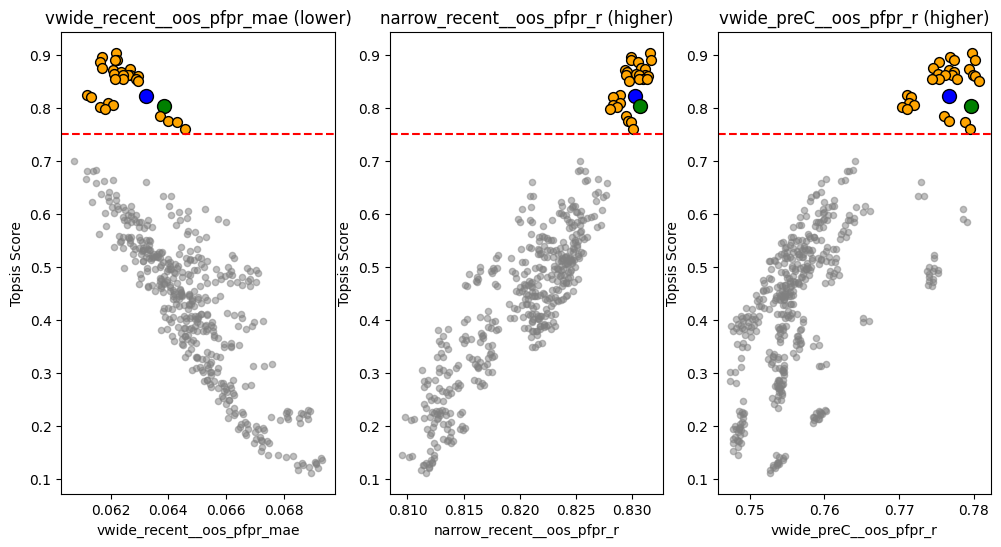

In [36]:
threshold = 0.75
fig, axes = plt.subplots(1, len(wm), figsize=(12, 6))
for i, col in enumerate(wm.keys()):
    ax = axes[i]
    spec_2_df = topsis_df[topsis_df['spec_index'] == 2]
    spec_3_df = topsis_df[topsis_df['spec_index'] == 3]
    good_spec_df = topsis_df[(topsis_df['topsis_score'] > threshold) & (topsis_df['spec_index'] != 2) & (topsis_df['spec_index'] != 3)]
    rest_spec_df = topsis_df[(topsis_df['topsis_score'] <= threshold) & (topsis_df['spec_index'] != 2) & (topsis_df['spec_index'] != 3)]
    ax.scatter(spec_2_df[col], spec_2_df['topsis_score'], color='blue', label='Spec 2', s=100, edgecolor='black')
    ax.scatter(spec_3_df[col], spec_3_df['topsis_score'], color='green', label='Spec 3', s=100, edgecolor='black')
    ax.scatter(good_spec_df[col], good_spec_df['topsis_score'], color='orange', label='Good Specs', s=50, edgecolor='black')
    ax.scatter(rest_spec_df[col], rest_spec_df['topsis_score'], color='gray', label='Rest Specs', s=20, alpha=0.5)
    ax.axhline(y=threshold, color='r', linestyle='--', label=f'Topsis Score Threshold ({threshold})')
    ax.set_xlabel(col)
    ax.set_ylabel('Topsis Score')
    ax.set_title(f'{col} ({wm[col]})')


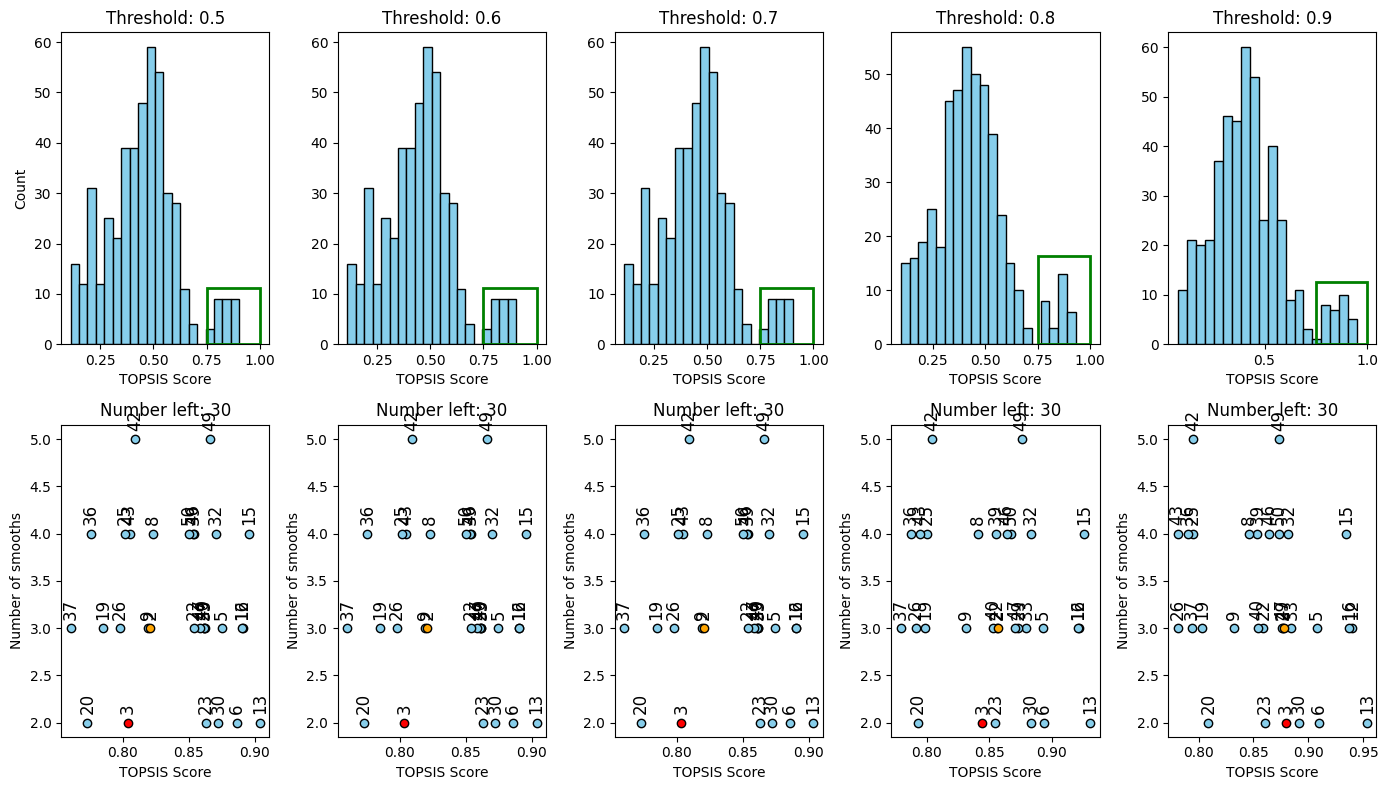

In [11]:
from matplotlib.patches import Rectangle
# Make a 1x5 figure each panel one threshold, histogram of topsis_score
fig, axes = plt.subplots(2, 5, figsize=(14, 8), sharey=False)
axes = axes.flatten()
cutoff_1 = 0.75
# cutoff_2 = 0.85
for i, threshold in enumerate(thresholds):
    ax = axes[i]
    subset = aggs[aggs['prune_threshold'] == threshold]
    counts, edges, _ = ax.hist(subset['topsis_score'], bins=20,
                               color='skyblue', edgecolor='black')
    ax.set_title(f'Threshold: {threshold}')
    ax.set_xlabel('TOPSIS Score')
    if i == 0:
        ax.set_ylabel('Count')

    # tallest bar whose bin overlaps [xlo, xhi], then a touch higher
    in_box = (edges[:-1] < 1.0) & (edges[1:] > cutoff_1)
    peak = counts[in_box].max() if in_box.any() else 0
    ax.add_patch(Rectangle((cutoff_1, 0), width=1.0 - cutoff_1, height=peak * 1.25,
                           fill=False, edgecolor='green', linewidth=2, zorder=5))


for i, threshold in enumerate(thresholds):
    ax = axes[i+5]
    subset = aggs[(aggs['prune_threshold'] == threshold) & (aggs['topsis_score'] > cutoff_1)]
    # Make spec 3 and 2 (if they show up) a differnt color scatter
    spec_3 = subset[subset['spec_index'] == 3]
    spec_2 = subset[subset['spec_index'] == 2]
    rest = subset[~subset['spec_index'].isin([2, 3])]

    ax.scatter(rest['topsis_score'], rest['n_smooths'],
               color='skyblue', edgecolor='black', zorder=3)
    ax.scatter(spec_3['topsis_score'], spec_3['n_smooths'],
               color='red', edgecolor='black', zorder=4)
    ax.scatter(spec_2['topsis_score'], spec_2['n_smooths'],
               color='orange', edgecolor='black', zorder=4)

    for j, (_, r) in enumerate(subset.iterrows()):
        ax.annotate(str(int(r['spec_index'])), (r['topsis_score'], r['n_smooths']),
                    textcoords='offset points', xytext=(0, 6),
                    rotation=90, ha='center', va='bottom', fontsize=12)

    ax.set_title(f'Number left: {len(subset)}')
    ax.set_xlabel('TOPSIS Score')
    ax.set_ylabel('Number of smooths')
    
# for i, threshold in enumerate(thresholds):
#     ax = axes[i+10]
#     subset = aggs[(aggs['prune_threshold'] == threshold) & (aggs['topsis_score'] > cutoff_2)]
#     spec_3 = subset[subset['spec_index'] == 3]
#     spec_2 = subset[subset['spec_index'] == 2]
#     rest = subset[~subset['spec_index'].isin([2, 3])]

#     ax.scatter(rest['topsis_score'], rest['n_smooths'],
#                color='skyblue', edgecolor='black', zorder=3)
#     ax.scatter(spec_3['topsis_score'], spec_3['n_smooths'],
#                color='red', edgecolor='black', zorder=4)
#     ax.scatter(spec_2['topsis_score'], spec_2['n_smooths'],
#                color='orange', edgecolor='black', zorder=4)

#     for j, (_, r) in enumerate(subset.iterrows()):
#         ax.annotate(str(int(r['spec_index'])), (r['topsis_score'], r['n_smooths']),
#                     textcoords='offset points', xytext=(0, 6),
#                     rotation=90, ha='center', va='bottom', fontsize=12)

#     ax.set_title(f'Number left: {len(subset)}')
#     ax.set_xlabel('TOPSIS Score')
#     ax.set_ylabel('Number of smooths')


plt.tight_layout()

In [16]:
cutoff = 0.75
hit_counts = (aggs.assign(hit=aggs['topsis_score'] > cutoff)
              .groupby('spec_index')['hit'].sum()
              .astype(int).sort_values(ascending=False))

print(len(hit_counts[hit_counts > 0]))        # specs that clear 0.8 in >=1 threshold, most-robust first
# save the specs that clear the cutoff in at least one threshold
final_specs = pd.DataFrame({
    'spec_index': hit_counts[hit_counts > 0].index,
    'hit_count': hit_counts[hit_counts > 0].values
}).reset_index(drop=True)
hit_counts[hit_counts > 0]


30


spec_index
47    5
49    5
50    5
43    5
19    5
12    5
13    5
15    5
16    5
20    5
22    5
46    5
25    5
26    5
29    5
30    5
32    5
33    5
36    5
37    5
39    5
40    5
42    5
23    5
2     5
3     5
5     5
6     5
9     5
8     5
Name: hit, dtype: int64

In [19]:
aggs

,spec_index,country_term,n_smooths,borda_rank,borda_score,topsis_rank,topsis_score,dominance_rank,dominance_count,consensus_rank,prune_threshold
0,13,FE,2,1.0,40.0,1.0,0.903693,2.0,457,1.333333,0.5
1,15,FE,4,4.0,49.0,2.0,0.895805,10.5,447,5.500000,0.5
2,16,FE,3,6.0,57.0,3.0,0.890608,6.5,451,5.166667,0.5
3,12,FE,3,2.5,47.0,4.0,0.890466,1.0,458,2.500000,0.5
4,6,FE,2,2.5,47.0,5.0,0.886076,8.5,450,5.333333,0.5
...,...,...,...,...,...,...,...,...,...,...,...
2290,153,FE,5,447.0,9045.0,455.0,0.091170,456.0,3,452.666667,0.9
2291,123,FE,3,450.0,9064.0,456.0,0.088920,455.0,4,453.666667,0.9
2292,136,FE,4,454.0,9115.0,457.0,0.085122,452.0,7,454.333333,0.9
2293,147,FE,4,455.0,9140.0,458.0,0.084146,459.0,0,457.333333,0.9


In [17]:
final_specs

,spec_index,hit_count
0,47,5
1,49,5
2,50,5
3,43,5
4,19,5
5,12,5
6,13,5
7,15,5
8,16,5
9,20,5


In [18]:
win_metrics

{'vwide_recent__oos_pfpr_mae': 'lower',
 'narrow_recent__oos_pfpr_r': 'higher',
 'vwide_preC__oos_pfpr_r': 'higher'}

In [ ]:
topsis_df[['spec_index'] + list(win_metrics.keys())].head(20)


,spec_index,vwide_recent__oos_pfpr_mae,narrow_recent__oos_pfpr_r,vwide_preC__oos_pfpr_r
0,13,0.062186,0.831636,0.779701
1,12,0.062153,0.831702,0.777300
2,16,0.062235,0.829921,0.780153
3,15,0.061711,0.829942,0.776849
4,6,0.061632,0.830543,0.775321
5,5,0.061693,0.830886,0.774470
6,30,0.062663,0.831224,0.779284
7,33,0.062658,0.829514,0.779927
8,32,0.062095,0.829426,0.776613
9,3,0.063848,0.830747,0.779545


In [97]:
cutoff = 0.875
hit_counts = (aggs.assign(hit=aggs['topsis_score'] > cutoff)
              .groupby('spec_index')['hit'].sum()
              .astype(int).sort_values(ascending=False))
print(len(hit_counts[hit_counts > 0]))        # specs that clear 0.8 in >=1 threshold, most-robust first
hit_counts[hit_counts > 0]

14


spec_index
12    5
6     5
13    5
15    5
16    5
5     2
30    2
32    2
33    2
49    1
47    1
29    1
3     1
2     1
Name: hit, dtype: int64

In [50]:
window_cols

['exwide_recent',
 'narrow_full',
 'narrow_preC',
 'narrow_recent',
 'vwide_full',
 'vwide_preC',
 'vwide_recent',
 'wide_full',
 'wide_preC',
 'wide_recent']

In [100]:
picks = pd.concat([
    agg.nsmallest(30, 'topsis_rank'),
]).drop_duplicates('spec_index')

across = ranked.set_index('spec_index').loc[picks.spec_index, window_cols]
across.insert(0, 'country_term', picks.set_index('spec_index')['country_term'])
display(across.round(4))
print('formulas:')
for sid in picks.spec_index:
    print(f'  spec {sid}:', ranked.loc[ranked.spec_index == sid, 'formula_text'].iloc[0])

,country_term,exwide_recent__oos_pfpr_r,narrow_full__oos_pfpr_r,narrow_preC__oos_pfpr_r,narrow_recent__oos_pfpr_r,vwide_full__oos_pfpr_r,vwide_preC__oos_pfpr_r,vwide_recent__oos_pfpr_r,wide_full__oos_pfpr_r,wide_preC__oos_pfpr_r,wide_recent__oos_pfpr_r
spec_index,,,,,,,,,,,
13,FE,0.8310,0.8018,0.7949,0.8316,0.7937,0.7797,0.8209,0.8011,0.7907,0.8245
12,FE,0.8307,0.8019,0.7948,0.8317,0.7918,0.7773,0.8210,0.8008,0.7903,0.8246
16,FE,0.8285,0.8016,0.7957,0.8299,0.7929,0.7802,0.8189,0.8008,0.7913,0.8226
15,FE,0.8287,0.8014,0.7950,0.8299,0.7904,0.7768,0.8194,0.8002,0.7902,0.8228
6,FE,0.8289,0.7990,0.7915,0.8305,0.7897,0.7753,0.8193,0.7979,0.7870,0.8233
5,FE,0.8288,0.7994,0.7921,0.8309,0.7889,0.7745,0.8195,0.7980,0.7872,0.8236
30,FE,0.8308,0.8014,0.7944,0.8312,0.7938,0.7793,0.8207,0.8005,0.7900,0.8240
33,FE,0.8284,0.8014,0.7953,0.8295,0.7931,0.7799,0.8188,0.8003,0.7908,0.8221
32,FE,0.8287,0.8011,0.7946,0.8294,0.7907,0.7766,0.8192,0.7998,0.7896,0.8225


formulas:
  spec 13: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_low_temperature + A0_af
  spec 12: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + s(malaria_suit, k = 6, bs = "mpi") + mean_low_temperature + A0_af
  spec 16: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + s(mean_low_temperature, k = 4) + A0_af
  spec 15: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + s(malaria_suit, k = 6, bs = "mpi") + s(mean_low_temperature, k = 4) + A0_af
  spec 6: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean, k = 4, bs = "mpd") + logit_malaria_suitability + mean_temperature + A0_af
  spec 5: logit_malaria_pfpr ~ s(mal_DAH_total_per_capita, k = 4, bs = "mpd") + s(gdppc_mean

In [92]:
is_stats = df[df.cell == 'IS'].set_index('spec_index')
is_cols  = [c for c in is_stats.columns if c.startswith('is_')]

agg_is = (agg
          .merge(is_stats[is_cols], left_on='spec_index', right_index=True, how='left')
          .merge(ranked[['spec_index'] + list(win_metrics.keys()) ], on='spec_index', how='left'))   # bring in the windows

base_cols = ['spec_index', 'country_term', 'n_smooths', 'topsis_rank']
is_show   = ['is_dev_expl', 'is_pfpr_r', 'is_r_sq', 'is_mae', 'is_pfpr_mae']
agg_is.sort_values('topsis_rank').head(15)[base_cols + list(win_metrics.keys()) + is_show].round(4)


,spec_index,country_term,n_smooths,topsis_rank,vwide_recent__oos_pfpr_mae,narrow_recent__oos_pfpr_r,vwide_preC__oos_pfpr_r,is_dev_expl,is_pfpr_r,is_r_sq,is_mae,is_pfpr_mae
0,13,FE,2,1.0,0.0622,0.8316,0.7797,0.8316,0.8543,0.8316,0.9123,0.0570
1,12,FE,3,2.0,0.0622,0.8317,0.7773,0.8319,0.8540,0.8319,0.9119,0.0571
2,16,FE,3,3.0,0.0622,0.8299,0.7802,0.8321,0.8541,0.8321,0.9116,0.0570
3,15,FE,4,4.0,0.0617,0.8299,0.7768,0.8324,0.8536,0.8324,0.9110,0.0571
4,6,FE,2,5.0,0.0616,0.8305,0.7753,0.8321,0.8538,0.8321,0.9111,0.0570
5,5,FE,3,6.0,0.0617,0.8309,0.7745,0.8325,0.8541,0.8325,0.9104,0.0571
6,30,FE,2,7.0,0.0627,0.8312,0.7793,0.8326,0.8550,0.8326,0.9106,0.0569
7,33,FE,3,8.0,0.0627,0.8295,0.7799,0.8331,0.8549,0.8331,0.9098,0.0569
8,32,FE,4,9.0,0.0621,0.8294,0.7766,0.8335,0.8542,0.8335,0.9091,0.0570
9,3,FE,2,10.0,0.0638,0.8307,0.7795,0.8306,0.8535,0.8306,0.9151,0.0572


In [ ]:
top10 = agg.sort_values('topsis_rank').head(10)
fmap = ranked.set_index('spec_index')['formula_text']
for _, r in top10.iterrows():
    print(f"topsis {r.topsis_rank:>6.1f}  [{r.country_term}]  spec {int(r.spec_index)}")
    print('   ', fmap[r.spec_index])


## 2. FE vs lag — best model, not averages

Best spec per country term by `consensus_rank`, then the head-to-head. (Remember the leakage caveat: lag winning is expected here.)

In [ ]:
best = agg.groupby('country_term', as_index=False).first()
display(best[['country_term', 'spec_index', 'n_smooths', 'borda_rank', 'topsis_rank', 'dominance_rank', 'consensus_rank']]
        .sort_values('consensus_rank').round(2))

fe_best  = agg.loc[agg.country_term == 'FE', 'consensus_rank'].min()
lag_best = agg.loc[agg.country_term.isin(['lag1', 'lag2', 'lag3']), 'consensus_rank'].min()
print(f'\nbest FE  consensus_rank : {fe_best:.2f}')
print(f'best lag consensus_rank : {lag_best:.2f}')
print('=> LAG gives the better model' if lag_best < fe_best else '=> FE gives the better model')

## 3. Candidate models laid out across windows

Overall top spec + best FE + best lag, shown as *actual models* across all windows (their `oos_pfpr_r` per window) — real trajectories, not per-window envelopes.

In [ ]:
picks = pd.concat([
    agg.nsmallest(1, 'topsis_rank'),
    agg[agg.country_term == 'FE'].nsmallest(1, 'topsis_rank'),
    agg[agg.country_term == 'lag1'].nsmallest(1, 'topsis_rank'),
    agg[agg.country_term == 'lag2'].nsmallest(1, 'topsis_rank'),
    agg[agg.country_term == 'lag3'].nsmallest(1, 'topsis_rank'),
]).drop_duplicates('spec_index')

across = ranked.set_index('spec_index').loc[picks.spec_index, window_cols]
across.insert(0, 'country_term', picks.set_index('spec_index')['country_term'])
display(across.round(4))
print('formulas:')
for sid in picks.spec_index:
    print(f'  spec {sid}:', ranked.loc[ranked.spec_index == sid, 'formula_text'].iloc[0])

## 4. Aggregate rank by complexity (borrowed boxplot)

Does more n_smooths buy a better *rank*? (lower = better)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for ix, col in enumerate(['borda_rank', 'topsis_rank']):
    agg.boxplot(column=col, by='n_smooths', ax=axes[ix])
    axes[ix].set_title(col); axes[ix].set_xlabel('n_smooths'); axes[ix].set_ylabel(col)
for ix, col in enumerate(['borda_rank', 'topsis_rank']):
    # Scatter plot of best rank vs n_smooths
    best_by_ns = agg.groupby('n_smooths', as_index=False).first()
    axes[ix + 2].scatter(best_by_ns['n_smooths'], best_by_ns[col])
    axes[ix + 2].set_title(f'best {col} by n_smooths'); axes[ix + 2].set_xlabel('n_smooths'); axes[ix + 2].set_ylabel(f'best {col}')
    axes[ix + 2].set_yscale('log')
plt.suptitle('Aggregate rank by n_smooths (lower = better)')
plt.tight_layout(); plt.show()

## 5. Frontier drop test — does the best model need each covariate?

`gain = min(consensus_rank | with) − min(consensus_rank | without)` (rank-space: **negative** = the best model *with* the covariate out-ranks the best without → keep; `>= 0` → drop candidate).

In [ ]:
fam_flags = ranked[['spec_index', 'suitability', 'temperature', 'humidity', 'urban', 'precip']]
base = agg.merge(fam_flags, on='spec_index')          # merge once, up front
rows = []
for country_term in base['country_term'].unique():
    sub = base[base['country_term'] == country_term]  # per-iteration copy, not `a`
    for k in ['suitability', 'temperature', 'humidity', 'urban', 'precip']:
        w = sub[k]
        best_with    = sub.loc[w, 'topsis_rank'].min()
        best_without = sub.loc[~w, 'topsis_rank'].min()
        rows.append({
            'country_term': country_term, 'family': k, 'n_with': int(w.sum()),
            'best_with_rank': best_with, 'best_without_rank': best_without,
            'gain': best_with - best_without})
pd.DataFrame(rows).sort_values('family').round(2)


In [ ]:
# per-SPECIFIC-covariate presence. \b word-boundaries so malaria_suit != logit_malaria_suitability
# and relative_humidity != logit_relative_humidity (each is a substring of its logit form).
specific_covs = {
    'malaria_suit'              : r'\bmalaria_suit\b',
    'logit_malaria_suitability' : r'\blogit_malaria_suitability\b',
    'mean_temperature'          : r'\bmean_temperature\b',
    'mean_low_temperature'      : r'\bmean_low_temperature\b',
    'weighted_1km_urban'        : r'weighted_1km_urban',
    'total_precipitation'       : r'\btotal_precipitation\b',
    'relative_humidity'         : r'\brelative_humidity\b',
    'logit_relative_humidity'   : r'\blogit_relative_humidity\b',
}
for name, pat in specific_covs.items():
    ranked[name] = ranked['formula_text'].str.contains(pat, regex=True)

cov_flags = ranked[['spec_index'] + list(specific_covs)]
base = agg.merge(cov_flags, on='spec_index')
rows = []
for country_term in base['country_term'].unique():
    sub = base[base['country_term'] == country_term]
    for k in specific_covs:
        w = sub[k]
        if w.sum() == 0 or (~w).sum() == 0:      # cov absent/ubiquitous in this term -> no contrast
            continue
        with_rank, without_rank = sub.loc[w, 'topsis_rank'].min(), sub.loc[~w, 'topsis_rank'].min()
        rows.append({
            'country_term': country_term, 'covariate': k, 'n_with': int(w.sum()),
            'best_with_rank': with_rank, 'best_without_rank': without_rank,
            'gain': with_rank - without_rank})
pd.DataFrame(rows).sort_values(['covariate', 'country_term']).round(2)
